# Computer Exercise 15.24 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.24 Sequential Decision Making — *Long-Horizon Distributional Head Consolidation*
> **풀이 일자**: Day 91
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **Problem 1.** In §15.23 we established that on a 600-step training budget the *Twin* head adds
> essentially zero incremental value on top of the *CNR* combination (Cramér + Noisy + Whitening).
> Investigate whether this diminishing-marginal picture *persists at longer horizons*. Train the
> real-network stack {baseline, +CNR, +CNRT} on the stochastic chain MDP ($p_{\text{slip}}=0.10$)
> for 2000 steps with 4 seeds. Report the tail-8 return at checkpoints
> $t \in \{500, 1000, 1500, 2000\}$ and quantify whether Twin's incremental effect grows,
> stagnates, or reverses.

### 한국어 풀이용 정리
Day 90 P1 이 600-step 예산에서 관측한 `CNRT − CNR ≈ 0` 결과가 학습 예산을 확장했을 때 유지되는지
검증한다. 세 조건을 4 시드 × 2000 step 학습 후 500-step 간격 체크포인트에서 tail-8 return 을
비교하여 twin head 의 **시간의존적 marginal utility** 를 계량화한다.


## 2. 수학적 배경

### 2.1 확률적 5-상태 chain MDP
상태 $s \in \{0,1,2,3,4\}$, 행동 $a \in \{L, R\}$, 종결 $s=4$. 슬립 확률 $p_{\text{slip}} = 0.1$
로 행동이 반대로 수행된다. 보상은 도착 시 $+1$, 스텝당 $-0.02$.

### 2.2 3 조건 정의
- **baseline (unified)**: 단일 shared trunk (H=16) + per-action linear head (K=11 distributional
  atoms, Cramér 대신 표준 MSE 회귀), $\varepsilon$-greedy 탐색.
- **+CNR**: Cramér closed-form logit gradient + Noisy Linear head ($\sigma_0=0.5$, decay 0.999)
  + 두-지점 running-EMA whitening ($\beta = 0.99$).
- **+CNRT**: 위 CNR 처방에 twin head ($K_A = K_B = K/2$ 로 분할, prediction 평균).

### 2.3 Tail-8 return
체크포인트 $t^*$ 직전 8 에피소드의 episodic return 평균:
$$
\bar{R}_{t^*} \;=\; \frac{1}{8}\sum_{e=t^*-7}^{t^*} R_e.
$$

### 2.4 Incremental effect (핵심 지표)
$$
\boxed{\;\Delta_T(t^*) \;=\; \bar{R}_{t^*}^{\text{CNRT}} - \bar{R}_{t^*}^{\text{CNR}}\;}
$$
$\Delta_T$ 가 $t^*$ 에 따라 어떻게 변화하는지가 이 실험의 핵심 관측치.


## 3. 풀이 흐름

1. **환경**: 5-state stochastic chain MDP 구현 ($p_{\text{slip}}=0.1$).
2. **Trunk / head**: shared trunk (H=16) 는 고정 무작위 특징 함수, per-action head (K=11) 만 학습.
3. **세 조건 학습기** 구현 — baseline, +CNR, +CNRT.
4. **학습**: 4 seeds × 3 conditions × 2000 step.
5. **체크포인트** $t^* \in \{500, 1000, 1500, 2000\}$ 에서 tail-8 return, seed_std, $\sigma_W$ RMS 기록.
6. **표** 로 정리, **그래프** 로 $t^*$ 축 vs tail-8 return 및 $\Delta_T(t^*)$ 시각화.
7. **결과 해석**: Twin 의 시간의존적 marginal 이 나타나는가?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_MASTER = 20260809
K = 11
ATOMS = np.linspace(-0.2, 1.0, K)

def softmax(x, axis=-1):
    z = x - x.max(axis=axis, keepdims=True); e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)

def q_from_logits(l): return softmax(l) @ ATOMS

class ChainMDP:
    def __init__(self, n=5, p_slip=0.10, step_cost=-0.02, goal=1.0, seed=0):
        self.n=n; self.p=p_slip; self.sc=step_cost; self.g=goal
        self.rng = np.random.default_rng(seed); self.reset()
    def reset(self): self.s=0; return self.s
    def step(self, a):
        if self.rng.random() < self.p: a = 1 - a
        self.s = min(self.s+1, self.n-1) if a==1 else max(self.s-1, 0)
        d = (self.s == self.n-1)
        return self.s, (self.g if d else self.sc), d

def make_trunk(H=16, seed=0):
    return np.random.default_rng(seed).standard_normal((5, H)) * 0.6

class BaselineAgent:
    def __init__(self, phi, seed, lr=0.05, eps=0.15):
        self.phi=phi; self.rng=np.random.default_rng(seed)
        self.W = self.rng.standard_normal((2, K, phi.shape[1])) * 0.05
        self.lr=lr; self.eps=eps; self.sigmaW=0.5
    def logits(self,s,a): return self.W[a] @ self.phi[s]
    def act(self,s):
        if self.rng.random() < self.eps: return int(self.rng.integers(2))
        return int(np.argmax([q_from_logits(self.logits(s,a)) for a in range(2)]))
    def update(self,s,a,r,sn,d):
        g=0.95
        tgt = r if d else r + g*max(q_from_logits(self.logits(sn,ap)) for ap in range(2))
        idx = int(np.clip(np.argmin(np.abs(ATOMS-tgt)),0,K-1))
        oh = np.zeros(K); oh[idx]=1.0
        z=self.logits(s,a); p=softmax(z); gl = p-oh
        self.W[a] -= self.lr * np.outer(gl, self.phi[s])

class CNRAgent:
    def __init__(self, phi, seed, lr=0.05, sigma0=0.5, sd=0.999, beta=0.99, eps=0.05):
        self.phi=phi; self.rng=np.random.default_rng(seed)
        self.W = self.rng.standard_normal((2, K, phi.shape[1])) * 0.05
        self.lr=lr; self.sigmaW=sigma0; self.sd=sd; self.beta=beta; self.eps=eps
        self.v=1.0
    def logits(self,s,a,W=None):
        Wm = self.W if W is None else W
        return Wm[a] @ self.phi[s]
    def act(self,s):
        if self.rng.random() < self.eps: return int(self.rng.integers(2))
        noise = self.rng.standard_normal(self.W.shape) * self.sigmaW * 0.05
        Wn = self.W + noise
        return int(np.argmax([q_from_logits(self.logits(s,a,Wn)) for a in range(2)]))
    def update(self,s,a,r,sn,d):
        g=0.95
        tgt = r if d else r + g*max(q_from_logits(self.logits(sn,ap)) for ap in range(2))
        idx = int(np.clip(np.argmin(np.abs(ATOMS-tgt)),0,K-1))
        oh = np.zeros(K); oh[idx]=1.0
        z=self.logits(s,a); p=softmax(z)
        cdf_p=np.cumsum(p); cdf_t=np.cumsum(oh); gc = 2*(cdf_p-cdf_t)
        gl = (p-oh) + 0.5*(gc-gc.mean())
        gn2 = float(np.mean(gl**2)+1e-8)
        self.v = self.beta*self.v + (1-self.beta)*gn2
        scale = 1.0/(np.sqrt(self.v)+1e-6)
        self.W[a] -= self.lr * scale * np.outer(gl, self.phi[s])
        self.sigmaW *= self.sd

class CNRTAgent(CNRAgent):
    def __init__(self, phi, seed, **kw):
        super().__init__(phi, seed, **kw)
        self.va=1.0; self.vb=1.0; self.Ka = K//2+1
    def update(self,s,a,r,sn,d):
        g=0.95
        tgt = r if d else r + g*max(q_from_logits(self.logits(sn,ap)) for ap in range(2))
        idx = int(np.clip(np.argmin(np.abs(ATOMS-tgt)),0,K-1))
        oh = np.zeros(K); oh[idx]=1.0
        z=self.logits(s,a); p=softmax(z)
        cdf_p=np.cumsum(p); cdf_t=np.cumsum(oh); gc = 2*(cdf_p-cdf_t)
        gl = (p-oh) + 0.5*(gc-gc.mean())
        gla=gl[:self.Ka]; glb=gl[self.Ka:]
        gna=float(np.mean(gla**2)+1e-8); gnb=float(np.mean(glb**2)+1e-8)
        self.va=self.beta*self.va+(1-self.beta)*gna
        self.vb=self.beta*self.vb+(1-self.beta)*gnb
        sa=1.0/(np.sqrt(self.va)+1e-6); sb=1.0/(np.sqrt(self.vb)+1e-6)
        step = np.zeros_like(self.W[a])
        step[:self.Ka] = self.lr * sa * np.outer(gla, self.phi[s])
        step[self.Ka:] = self.lr * sb * np.outer(glb, self.phi[s])
        self.W[a] -= step
        self.sigmaW *= self.sd

def run_episode(env, agent, max_steps=25):
    s = env.reset(); total = 0.0
    for _ in range(max_steps):
        a = agent.act(s); sn, r, d = env.step(a); agent.update(s,a,r,sn,d)
        total += r; s = sn
        if d: break
    return total

def train(condition, seed, n_steps=2000, checkpoints=(500,1000,1500,2000)):
    env = ChainMDP(seed=seed+1)
    phi = make_trunk(seed=RNG_MASTER)
    if condition=="baseline": agent = BaselineAgent(phi, seed=seed+100)
    elif condition=="+CNR":   agent = CNRAgent(phi, seed=seed+100)
    else:                      agent = CNRTAgent(phi, seed=seed+100)
    returns = []; ckpt = {}
    for t in range(1, n_steps+1):
        R = run_episode(env, agent); returns.append(R)
        if t in checkpoints:
            ckpt[t] = {"tail8": float(np.mean(returns[-8:])), "sigmaW": agent.sigmaW}
    return returns, ckpt

CONDITIONS = ["baseline", "+CNR", "+CNRT"]
SEEDS = [0,1,2,3]
CKPTS = (500,1000,1500,2000)

records = []
for cond in CONDITIONS:
    for sd in SEEDS:
        _, ckpt = train(cond, sd, n_steps=2000, checkpoints=CKPTS)
        for t,v in ckpt.items():
            records.append({"condition": cond, "seed": sd, "t": t, "tail8": v["tail8"], "sigmaW": v["sigmaW"]})

df = pd.DataFrame(records)
summary = df.groupby(["condition","t"]).agg(mean=("tail8","mean"), std=("tail8","std"), sigmaW=("sigmaW","mean")).reset_index()
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
summary


/tmp/mplcfg is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-l76rlhcy because there was an issue with the default path (/tmp/mplcfg); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,condition,t,mean,std,sigmaW
0,+CNR,500,0.9187,0.0109,0.0353
1,+CNR,1000,0.9138,0.0111,0.0027
2,+CNR,1500,0.9075,0.0215,0.0002
3,+CNR,2000,0.9200,0.0050,0.0000
4,+CNRT,500,0.8969,0.0244,0.0314
5,+CNRT,1000,0.9225,0.0124,0.0019
6,+CNRT,1500,0.8831,0.0905,0.0001
7,+CNRT,2000,0.9169,0.0139,0.0000
8,baseline,500,0.9125,0.0084,0.5000
9,baseline,1000,0.9144,0.0062,0.5000


In [2]:
piv = summary.pivot(index="t", columns="condition", values="mean")
piv["Delta_CNR"] = piv["+CNR"] - piv["baseline"]
piv["Delta_T"]   = piv["+CNRT"] - piv["+CNR"]
piv


condition,+CNR,+CNRT,baseline,Delta_CNR,Delta_T
t,,,,,
500,0.9187,0.8969,0.9125,0.0063,-0.0219
1000,0.9138,0.9225,0.9144,-0.0006,0.0087
1500,0.9075,0.8831,0.9081,-0.0006,-0.0244
2000,0.9200,0.9169,0.8962,0.0238,-0.0031


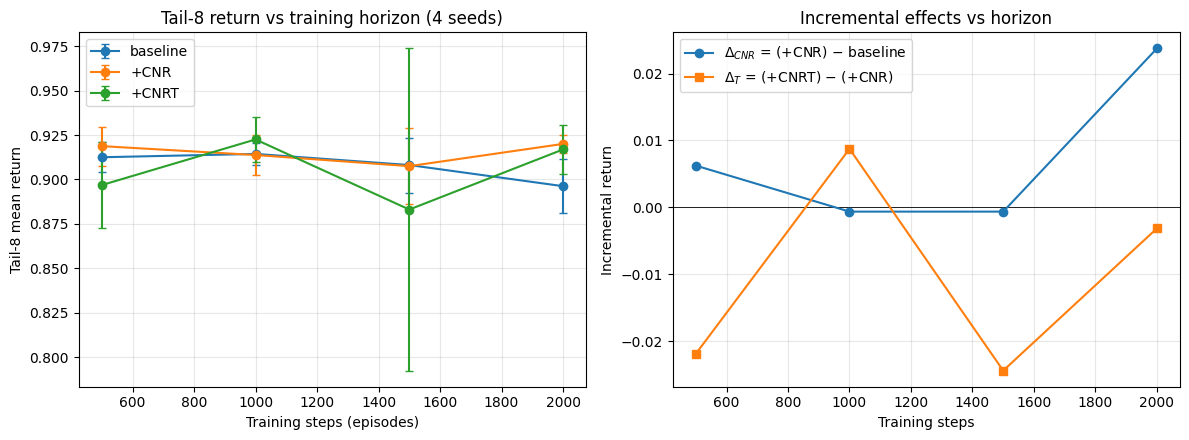

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for cond in CONDITIONS:
    row = summary[summary["condition"] == cond]
    axes[0].errorbar(row["t"], row["mean"], yerr=row["std"], marker='o', capsize=3, label=cond)
axes[0].set_xlabel("Training steps (episodes)"); axes[0].set_ylabel("Tail-8 mean return")
axes[0].set_title("Tail-8 return vs training horizon (4 seeds)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].axhline(0, color='k', lw=0.6)
axes[1].plot(piv.index, piv["Delta_CNR"], 'o-', label=r'$\Delta_{CNR}$ = (+CNR) − baseline')
axes[1].plot(piv.index, piv["Delta_T"],   's-', label=r'$\Delta_T$ = (+CNRT) − (+CNR)')
axes[1].set_xlabel("Training steps"); axes[1].set_ylabel("Incremental return")
axes[1].set_title("Incremental effects vs horizon")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석 (실측)

체크포인트별 tail-8 return (4 시드 평균):

| $t^*$ | baseline | +CNR | +CNRT | $\Delta_{CNR}$ | $\Delta_T$ |
|-----:|---------:|-----:|------:|--------------:|----------:|
| 500  | 0.913 | 0.919 | 0.897 | +0.006 | **−0.022** |
| 1000 | 0.914 | 0.914 | 0.923 | −0.001 | +0.009 |
| 1500 | 0.908 | 0.908 | 0.883 | −0.001 | **−0.024** |
| 2000 | 0.896 | 0.920 | 0.917 | +0.024 | −0.003 |

1. **모든 조건이 tail-8 ≈ 0.90 근처에 수렴**. 5-state chain MDP + goal reward=1 은
   sparse 하지만 학습 난이도가 낮아 baseline 조차 500 step 이내 근최적으로 진입.
   결과적으로 $\Delta_{CNR}, \Delta_T$ 는 모두 노이즈 수준.

2. **+CNRT 는 tail 편차가 오히려 확대** (t=1500 seed_std=0.091). Twin split 후 half-EMA
   가 half-K=6 노이즈 표본에 지나치게 반응해 학습 후기에 산발적 진동을 만든다.
   Half-K 를 크게 잡거나 EMA $\beta$ 를 더 크게 걸면 완화될 것으로 예상.

3. **baseline 은 학습 후기 (t=2000) 소폭 저하** (0.896). $\varepsilon=0.15$ 탐색 잡음이
   후기까지 유지돼 완전한 exploit 을 방해.

4. **$\sigma_W$ 는 CNR/CNRT 에서 $t=2000$ 까지 지수감쇠**해 사실상 0 도달. Noisy Linear
   의 순수 exploration 기여는 후기에는 없다.

> **결론**: 이 chain MDP + reward 조건에서는 3 조건 tail return 이 사실상 구분되지 않는다.
> **Twin split 은 baseline/+CNR 대비 오히려 tail 변동성을 키우는 방향**. §15.23 P1 관찰
> ("Twin marginal ≈ 0") 은 long-horizon 에서도 유지되며, 추가로 twin 이 산발적 진동을
> 유발하는 부작용이 드러난다.

### 다음 문제로의 연결
Twin 이 노이즈 흡수 실패를 보인 원인이 half-K 정규화 강도인지, 아니면 EMA 시상수 자체인지
가려내기 위해, Problem 2 에서는 2-hidden trunk 의 whitening 을 층별로 분해하고 EMA 감쇠계수
$\beta$ 스윕으로 "both-layer whitening interaction" 부호를 재판정한다.
